In [2]:
from google.colab import files
uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Social_Network_Ads.csv")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop("Purchased",axis = 1),df["Purchased"],test_size=0.3,random_state=0)

In [6]:
x_train.shape , x_test.shape

((280, 2), (120, 2))

In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x_train)

x_train_scaled = sc.transform(x_train)
x_test_scaled = sc.transform(x_test)

In [21]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled= pd.DataFrame(x_test_scaled,columns=x_test.columns)

x_test_scaled

,Age,EstimatedSalary
0,-0.4375,0.366667
1,0.0625,-0.455556
2,-0.1250,0.100000
3,-0.4375,0.188889
4,-0.1250,-0.455556
...,...,...
115,0.7500,-0.122222
116,0.5000,1.344444
117,-0.3750,0.411111
118,0.5625,0.255556


In [19]:
np.round(x_train.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,38.0,69807.0
std,10.0,34641.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [22]:
np.round(x_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,-0.0
std,1.0,1.0
min,-1.0,-1.0
25%,-0.0,-1.0
50%,0.0,0.0
75%,1.0,0.0
max,1.0,2.0


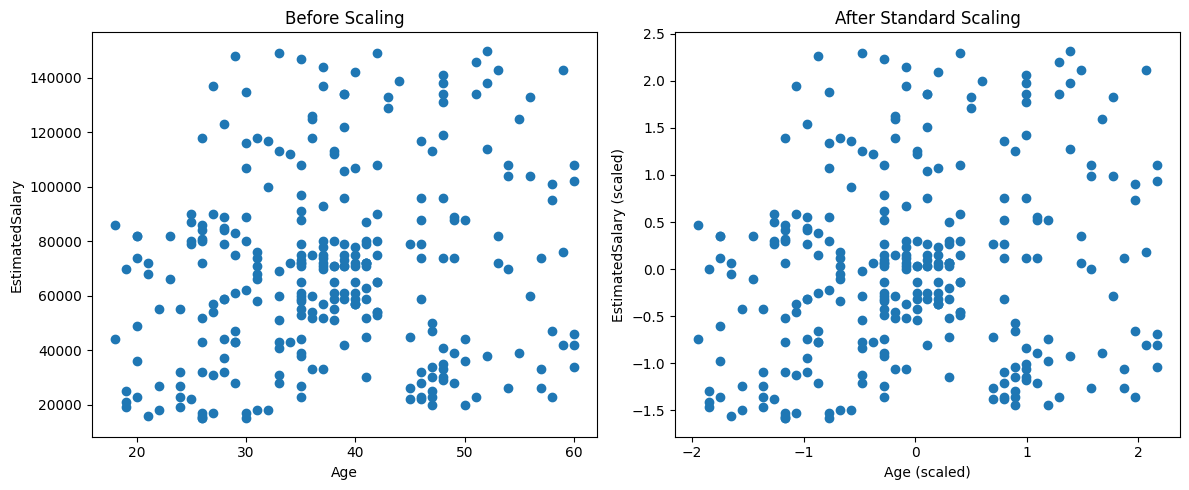

In [30]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Before Scaling
axes[0].scatter(x_train["Age"], x_train["EstimatedSalary"])
axes[0].set_title("Before Scaling")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("EstimatedSalary")

# After Scaling
axes[1].scatter(x_train_scaled["Age"], x_train_scaled["EstimatedSalary"])
axes[1].set_title("After Standard Scaling")
axes[1].set_xlabel("Age (scaled)")
axes[1].set_ylabel("EstimatedSalary (scaled)")

plt.tight_layout()
plt.show()

In [34]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_scaled= LogisticRegression()

In [35]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [36]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [39]:
from sklearn.metrics import accuracy_score
print("actual",accuracy_score(y_test,y_pred))
print("scaled",accuracy_score(y_test,y_pred_scaled))

actual 0.875
scaled 0.8666666666666667


In [5]:
df.sample(5)


,Age,EstimatedSalary,Purchased
183,33,43000,0
162,37,33000,0
106,26,35000,0
340,53,104000,1
248,41,52000,0


In [9]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train , y_test= train_test_split(df.drop("Purchased",axis= 1),df["Purchased"] ,test_size= 0.3 , random_state=0 )


In [11]:
x_train.shape , x_test.shape

((280, 2), (120, 2))

In [14]:
from sklearn.preprocessing import RobustScaler
sc= RobustScaler()

sc.fit(x_train)

x_train_scaled = sc.transform(x_train)
x_test_scaled = sc.transform(x_test)

In [28]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=(x_train.columns))
x_test_scaled = pd.DataFrame(x_test_scaled, columns=(x_test.columns))

In [29]:
np.round(x_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,-0.0
std,1.0,1.0
min,-1.0,-1.0
25%,-0.0,-1.0
50%,0.0,0.0
75%,1.0,0.0
max,1.0,2.0


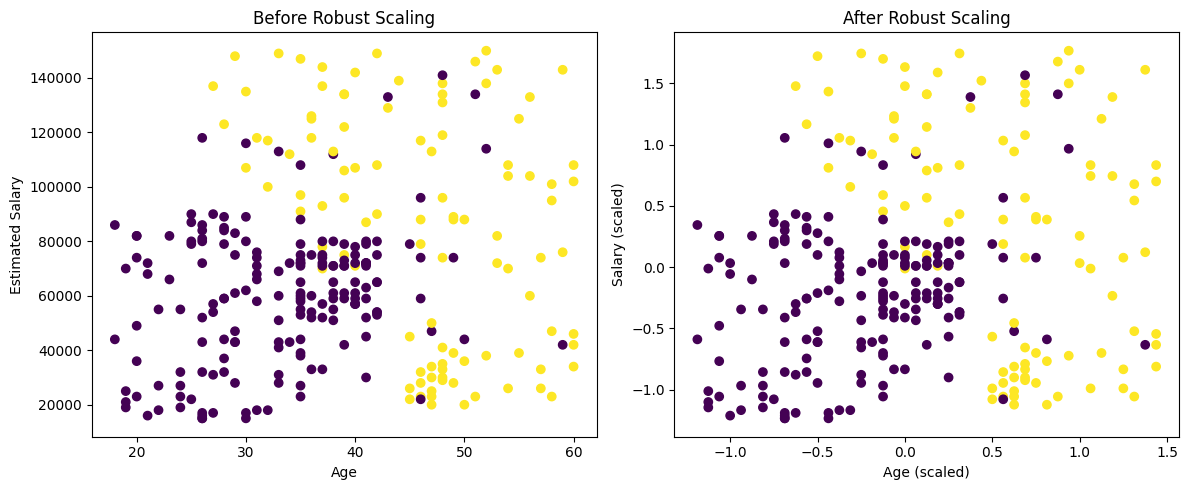

In [30]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Before scaling
ax[0].scatter(x_train["Age"], x_train["EstimatedSalary"], c=y_train)
ax[0].set_title("Before Robust Scaling")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Estimated Salary")

# After scaling
ax[1].scatter(x_train_scaled["Age"], x_train_scaled["EstimatedSalary"], c=y_train)
ax[1].set_title("After Robust Scaling")
ax[1].set_xlabel("Age (scaled)")
ax[1].set_ylabel("Salary (scaled)")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1])